# Plate Whisperer
## A Generative Plate Reverb via Flow-Matched Modal Inference

**ECS7022P Computational Creativity — coursework notebook**

This notebook is the interface for *Plate Whisperer*: a generative audio-effects system that takes any plate impulse response, infers its modal parameters using a trained DeepSets flow-matching model, and convolves the resulting filter bank with arbitrary user audio to produce **wet (reverberated) audio artefacts**.

**Workflow at a glance:**

1. Pick a plate (a target IR — choose from the bundled bank, or upload your own)
2. Run the trained flow-matching model — get a set of inferred modes
3. Resynthesise a clean IR from the modes
4. Upload your own dry audio (a melody, voice, drum loop) — apply the plate reverb
5. Audition multiple stochastic plates from the same IR (mutant shopping)
6. Run the plate gallery — same dry audio through three different plates

Inline audio playback at every stage. Re-run section 2 with a different random seed for a different stochastic plate from the same IR.

---
## 0. Setup

Install dependencies and import. If running on Colab, the `!pip` line below will install the required packages; on a local install with the project repo cloned, it can be skipped.

In [1]:
import sys, os
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Detected Google Colab. Cloning repository...")
    !git clone https://github.com/ptablasdpaula/challenge.git
    %cd challenge
    !pip install pytorch-lightning soundfile

import numpy as np
import torch
import scipy.signal
import soundfile as sf
import IPython.display as ipd
import matplotlib.pyplot as plt

REPO = Path().resolve()
print(f'Repo root: {REPO}')
assert (REPO / 'core').exists(), \
    f'`core/` not found under {REPO}. Adjust REPO to point at your project root.'

sys.path.insert(0, str(REPO / 'core'))

from dataset import (
    compute_log_mag_fft,
    denormalise_f0, denormalise_sigma, denormalise_gain,
)
from train_module import ModalFlowMatchingModule

DEVICE = 'cpu'
SEED = 0
torch.manual_seed(SEED); np.random.seed(SEED)

Repo root: /Users/pablotablasdepaula/PycharmProjects/challenge


---
## 1. Load the trained model

The checkpoint is the result of training the DeepSets flow-matching model on ~3,000 synthetic plate IRs generated from the Kirchhoff–Love simulator. No pre-trained weights from elsewhere are used — these are mine.

In [2]:
CKPT_PATH = REPO / 'core' / 'checkpoints' / 'deepsets.ckpt'
print(f'Loading checkpoint: {CKPT_PATH}')

model = ModalFlowMatchingModule.load_from_checkpoint(
    str(CKPT_PATH),
    map_location=DEVICE,
    weights_only=False,
)
model.eval().to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f'Model loaded — {n_params:,} parameters')
print(f'  d_model    : {model.hparams.d_model}')
print(f'  n_layers   : {model.hparams.n_layers}')
print(f'  d_cond     : {model.hparams.d_cond}')

Loading checkpoint: /Users/pablotablasdepaula/PycharmProjects/challenge/core/checkpoints/deepsets.ckpt
Model loaded — 17,490,436 parameters
  d_model    : 256
  n_layers   : 8
  d_cond     : 256


---
## 2. Pick a plate

Each plate is described by an impulse response (IR). The bank below ships with the project. Change `PLATE_ID` to audition a different one — they cover a range of sizes, tensions and decay times.

Available plates (16): ['0001', '0002', '0003', '0004', '0005', '0006', '0007', '0008', '0009', '0010']...

Plate 0001: 220500 samples @ 44100 Hz (5.00s)
Truncated to 176400 samples (4.0s)

▶ Source plate IR (audio):


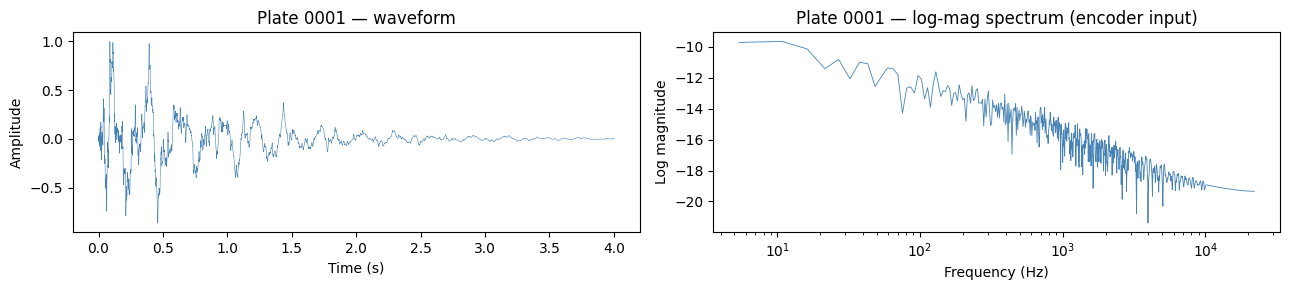

In [13]:
STRIPPED_DIR    = REPO / '2026-DATASET-STRIPPED'
TARGET_DURATION = 4.0       # seconds — model was trained on 4s IRs
N_FFT           = 8192

# Show the bank — change PLATE_ID to audition a different plate
available = sorted([p.stem.split('_')[-1] for p in STRIPPED_DIR.glob('random_IR_[0-9]*.npz')])
print(f'Available plates ({len(available)}): {available[:10]}{"..." if len(available) > 10 else ""}')

PLATE_ID = '0001'        # <-- change me to pick a different plate
NPZ_PATH = STRIPPED_DIR / f'random_IR_{PLATE_ID}.npz'

data    = np.load(NPZ_PATH)
ir_full = data['ir'].astype(np.float64)
sr      = int(data['sample_rate'])

n_target = int(TARGET_DURATION * sr)
ir       = ir_full[:n_target].copy()
ir_norm  = ir / (np.max(np.abs(ir)) + 1e-10)

print(f'\nPlate {PLATE_ID}: {len(ir_full)} samples @ {sr} Hz ({len(ir_full)/sr:.2f}s)')
print(f'Truncated to {len(ir)} samples ({TARGET_DURATION}s)\n')

print('▶ Source plate IR (audio):')
ipd.display(ipd.Audio(ir_norm, rate=sr))

t_axis = np.linspace(0, TARGET_DURATION, len(ir))
fig, axes = plt.subplots(1, 2, figsize=(13, 3))
axes[0].plot(t_axis, ir_norm, lw=0.4, color='steelblue')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Amplitude')
axes[0].set_title(f'Plate {PLATE_ID} — waveform')

freqs = np.fft.rfftfreq(N_FFT, d=1.0/sr)
log_mag = compute_log_mag_fft(ir, n_fft=N_FFT)
axes[1].semilogx(freqs[1:], log_mag[1:], lw=0.6, color='steelblue')
axes[1].set_xlabel('Frequency (Hz)'); axes[1].set_ylabel('Log magnitude')
axes[1].set_title(f'Plate {PLATE_ID} — log-mag spectrum (encoder input)')
plt.tight_layout(); plt.show()

---
## 3. Run the flow-matching model — infer the modes

Encoder → conditioning vector z → DeepSets vector field → integrate ODE → modal parameters.

Three knobs the user can play with:
- `N_NOISE_TOKENS`: how many candidate modes to seed (more = denser plate, slower)
- `VAL_STEPS`: RK4 ODE steps (more = sharper output, slower)
- `CFG_STRENGTH`: classifier-free guidance — higher pulls predictions toward the conditioning IR more aggressively

In [14]:
N_NOISE_TOKENS = 500
VAL_STEPS      = 15
CFG_STRENGTH   = 2.0

EXISTS_THRESH  = 0.5

log_mag_t = torch.from_numpy(log_mag).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    z = model.encoder(log_mag_t)
    noise    = torch.randn(1, N_NOISE_TOKENS, 4, device=DEVICE)
    sort_idx = noise[..., 0].argsort(dim=1)
    noise    = torch.gather(noise, 1, sort_idx.unsqueeze(-1).expand_as(noise))
    print(f'Running RK4 ODE: {VAL_STEPS} steps × {N_NOISE_TOKENS} tokens')
    pred = model._sample(z, noise, steps=VAL_STEPS, cfg=CFG_STRENGTH)

pred_np      = pred[0].cpu().float().numpy()
exists_mask  = pred_np[:, 3] > EXISTS_THRESH
pred_real    = pred_np[exists_mask]

print(f'Tokens sampled:   {N_NOISE_TOKENS}')
print(f'Modes identified: {len(pred_real)}')

Running RK4 ODE: 15 steps × 500 tokens
Tokens sampled:   500
Modes identified: 500


---
## 4. Denormalise and inspect the inferred modal bank

f0    range: [6.1, 10355.2] Hz
sigma range: [0.62, 879.60] s⁻¹
gain  range: [-1.90e-10, 2.23e-10]


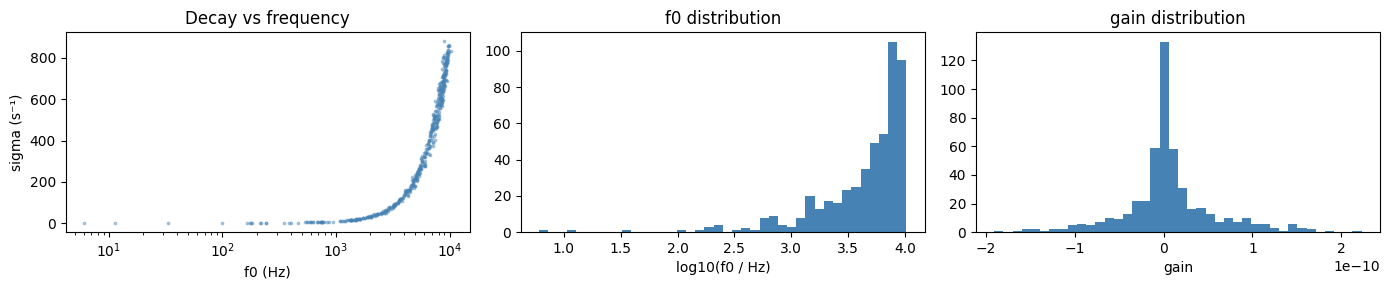

In [15]:
f0_pred    = denormalise_f0(pred_real[:, 0])
sigma_pred = denormalise_sigma(pred_real[:, 1])
gain_pred  = denormalise_gain(pred_real[:, 2])

sort       = np.argsort(f0_pred)
f0_pred    = f0_pred[sort]
sigma_pred = sigma_pred[sort]
gain_pred  = gain_pred[sort]

print(f'f0    range: [{f0_pred.min():.1f}, {f0_pred.max():.1f}] Hz')
print(f'sigma range: [{sigma_pred.min():.2f}, {sigma_pred.max():.2f}] s⁻¹')
print(f'gain  range: [{gain_pred.min():.2e}, {gain_pred.max():.2e}]')

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
axes[0].scatter(f0_pred, sigma_pred, s=3, alpha=0.4, color='steelblue')
axes[0].set_xscale('log')
axes[0].set_xlabel('f0 (Hz)'); axes[0].set_ylabel('sigma (s⁻¹)')
axes[0].set_title('Decay vs frequency')
axes[1].hist(np.log10(np.maximum(f0_pred, 1e-3)), bins=40, color='steelblue')
axes[1].set_xlabel('log10(f0 / Hz)'); axes[1].set_title('f0 distribution')
axes[2].hist(gain_pred, bins=40, color='steelblue')
axes[2].set_xlabel('gain'); axes[2].set_title('gain distribution')
plt.tight_layout(); plt.show()

---
## 5. Resynthesise a clean IR from the inferred modes

$$\text{IR}(t) = \sum_{k=1}^{M} g_k \cdot e^{-\sigma_k t} \cdot \sin(2\pi f_k t)$$

Sums over inferred modes in chunks of 200 to bound memory.

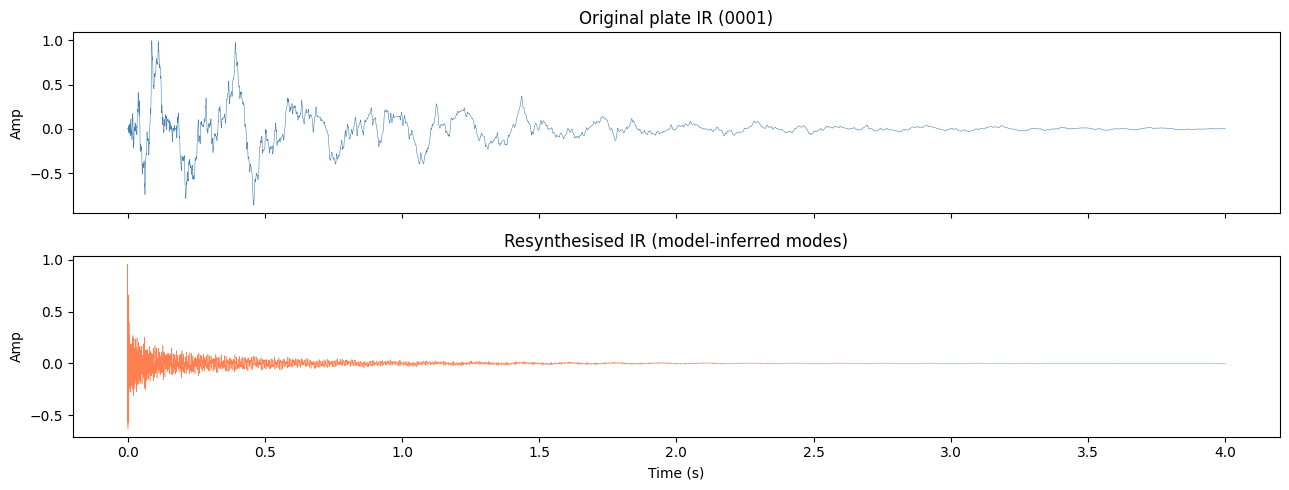

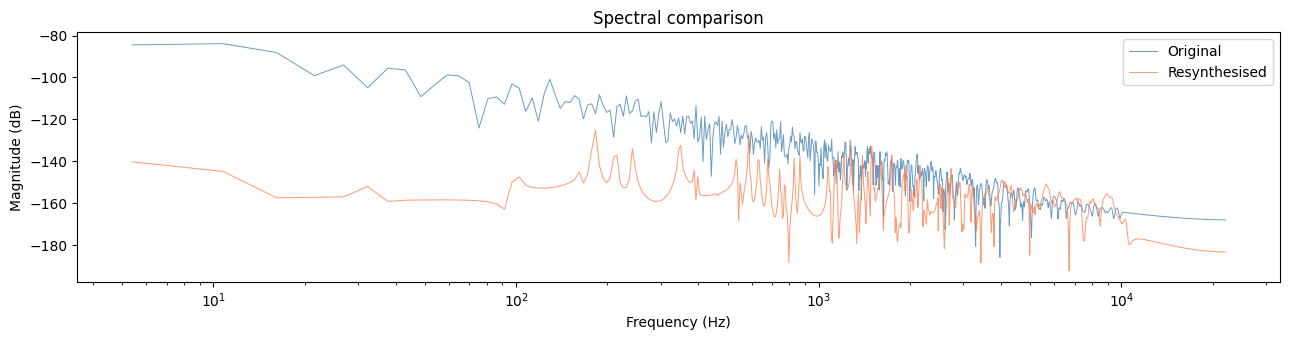

▶ Original plate IR:


▶ Resynthesised IR (this is what we will convolve with):


In [16]:
def kirchhoff_modal_synthesis(f0, sigma, gain, sr, duration, chunk=200):
    N      = int(duration * sr)
    t      = np.arange(N, dtype=np.float64) / sr
    output = np.zeros(N, dtype=np.float64)
    for s in range(0, len(f0), chunk):
        f0_c  = f0[s:s+chunk][None, :]
        sig_c = sigma[s:s+chunk][None, :]
        g_c   = gain[s:s+chunk][None, :]
        t_col = t[:, None]
        output += (g_c * np.exp(-sig_c * t_col) *
                   np.sin(2 * np.pi * f0_c * t_col)).sum(axis=1)
    return output

ir_synth      = kirchhoff_modal_synthesis(f0_pred, sigma_pred, gain_pred,
                                           sr=sr, duration=TARGET_DURATION)
ir_synth_norm = ir_synth / (np.max(np.abs(ir_synth)) + 1e-10)

fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
axes[0].plot(t_axis, ir_norm,       lw=0.4, color='steelblue')
axes[0].set_ylabel('Amp'); axes[0].set_title(f'Original plate IR ({PLATE_ID})')
axes[1].plot(t_axis, ir_synth_norm, lw=0.4, color='coral')
axes[1].set_ylabel('Amp'); axes[1].set_title('Resynthesised IR (model-inferred modes)')
axes[1].set_xlabel('Time (s)')
plt.tight_layout(); plt.show()

# Spectral overlay
def log_mag_spectrum(x, n_fft, sr):
    x_pad = x[:n_fft] if len(x) >= n_fft else np.pad(x, (0, n_fft - len(x)))
    spec  = np.fft.rfft(x_pad)
    return np.fft.rfftfreq(n_fft, d=1.0/sr), 20*np.log10(np.abs(spec)+1e-10)

f_o, m_o = log_mag_spectrum(ir,       N_FFT, sr)
f_s, m_s = log_mag_spectrum(ir_synth, N_FFT, sr)
plt.figure(figsize=(13, 3.5))
plt.semilogx(f_o[1:], m_o[1:], lw=0.7, color='steelblue', alpha=0.8, label='Original')
plt.semilogx(f_s[1:], m_s[1:], lw=0.7, color='coral',     alpha=0.8, label='Resynthesised')
plt.xlabel('Frequency (Hz)'); plt.ylabel('Magnitude (dB)')
plt.title('Spectral comparison'); plt.legend(); plt.tight_layout(); plt.show()

print('▶ Original plate IR:')
ipd.display(ipd.Audio(ir_norm,       rate=sr))
print('▶ Resynthesised IR (this is what we will convolve with):')
ipd.display(ipd.Audio(ir_synth_norm, rate=sr))

---
## 6. The artefact: bring your own dry audio and run it through the plate

**This is where the system produces its actual creative artefact** — a piece of audio reverberated by an inferred plate.

Two options below. Pick one:
- **Option A (instant)**: use the built-in test signal (a triangular-wave chord and arpeggio)
- **Option B (BYO audio)**: upload your own mono WAV file

In [17]:
# ── Option A — built-in test signal ──────────────────────────────────────────
def make_tri(freq, duration, sr=sr):
    t = np.linspace(0, duration, int(sr * duration), endpoint=False)
    return scipy.signal.sawtooth(2 * np.pi * freq * t, width=0.5)

duration_chord = 2.0
c_sharp_maj = (make_tri(277.18, duration_chord) +
               make_tri(349.23, duration_chord) +
               make_tri(415.30, duration_chord)) / 3.0

duration_note = 0.3
f_locrian_arp = np.concatenate([
    make_tri(174.61, duration_note),       # F3
    make_tri(185.00, duration_note),       # Gb3
    make_tri(207.65, duration_note),       # Ab3
    make_tri(246.94, duration_note),       # Cb4/B3
    make_tri(311.13, duration_note * 2),   # Eb4
])

dry_audio = np.concatenate([c_sharp_maj, np.zeros(sr), f_locrian_arp])
dry_audio = dry_audio / (np.max(np.abs(dry_audio)) + 1e-10)

print('▶ Dry audio (Option A — test signal):')
ipd.display(ipd.Audio(dry_audio, rate=sr))

▶ Dry audio (Option A — test signal):


In [18]:
# ── Option B — upload your own dry audio ─────────────────────────────────────

from google.colab import files
uploaded = files.upload()
upload_path = next(iter(uploaded.keys()))

user_audio, user_sr = sf.read(upload_path)
if user_audio.ndim > 1:
    user_audio = user_audio.mean(axis=1)
if user_sr != sr:
    n_resamp = int(len(user_audio) * sr / user_sr)
    user_audio = scipy.signal.resample(user_audio, n_resamp)
user_audio = user_audio / (np.max(np.abs(user_audio)) + 1e-10)

dry_audio = user_audio.astype(np.float64)
print('▶ Dry audio (Option B — your upload):')
ipd.display(ipd.Audio(dry_audio, rate=sr))

ModuleNotFoundError: No module named 'google.colab'

In [19]:
# Apply the inferred-plate reverb via FFT convolution
wet_audio = scipy.signal.fftconvolve(dry_audio, ir_synth_norm, mode='full')
wet_audio = wet_audio / (np.max(np.abs(wet_audio)) + 1e-10)

print('▶ Wet audio (dry signal projected through the inferred plate):')
ipd.display(ipd.Audio(wet_audio, rate=sr))

# Save to disk so it can be downloaded
out_path = REPO / f'wet_audio_plate_{PLATE_ID}_seed_{SEED}.wav'
sf.write(str(out_path), wet_audio.astype(np.float32), sr)
print(f'Saved wet audio to: {out_path}')

▶ Wet audio (dry signal projected through the inferred plate):


Saved wet audio to: /Users/pablotablasdepaula/PycharmProjects/challenge/wet_audio_plate_0001_seed_0.wav


---
## 7. Mutant shopping: re-roll the same plate stochastically

The flow-matching sampler is stochastic — a fresh batch of Gaussian noise yields a slightly different inferred plate, even from the same conditioning IR. This cell generates three variants from the *same* source IR and convolves the dry audio through each.

In [22]:
from tqdm.auto import tqdm
from train_module import rk4_step

def infer_and_resynth(ir_in, sr, n_tokens=500, steps=15, cfg=2.0, seed=0, leave_inner=False):
    """End-to-end: IR -> modes -> resynth IR."""
    torch.manual_seed(seed); np.random.seed(seed)
    log_mag_in = compute_log_mag_fft(ir_in, n_fft=N_FFT)
    log_mag_t  = torch.from_numpy(log_mag_in).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        z = model.encoder(log_mag_t)
        noise    = torch.randn(1, n_tokens, 4, device=DEVICE)
        sort_idx = noise[..., 0].argsort(dim=1)
        noise    = torch.gather(noise, 1, sort_idx.unsqueeze(-1).expand_as(noise))

        sample = noise
        t      = torch.zeros(noise.shape[0], 1, device=DEVICE)
        dt     = 1.0 / steps

        for _ in tqdm(range(steps), desc=f"Variant {seed} ODE Steps", leave=leave_inner):
            sample = rk4_step(model.vector_field, sample, t, dt, conditioning=z, cfg_strength=cfg)
            t = t + dt
        pred = sample

    pred_np   = pred[0].cpu().float().numpy()
    pred_real = pred_np[pred_np[:, 3] > 0.5]
    f0    = denormalise_f0(pred_real[:, 0])
    sigma = denormalise_sigma(pred_real[:, 1])
    gain  = denormalise_gain(pred_real[:, 2])

    ir_out = kirchhoff_modal_synthesis(f0, sigma, gain, sr, TARGET_DURATION)
    ir_out = ir_out / (np.max(np.abs(ir_out)) + 1e-10)
    return ir_out, len(f0)

In [23]:
variant_seed = 1
ir_v, n_modes_v = infer_and_resynth(ir, sr, seed=variant_seed, leave_inner=False)
wet_v = scipy.signal.fftconvolve(dry_audio, ir_v, mode='full')
wet_v = wet_v / (np.max(np.abs(wet_v)) + 1e-10)
print(f'\n▶ Variant {variant_seed} — {n_modes_v} modes:')
ipd.display(ipd.Audio(wet_v, rate=sr))


▶ Variant 1 — 500 modes:


In [24]:
variant_seed = 2
ir_v, n_modes_v = infer_and_resynth(ir, sr, seed=variant_seed, leave_inner=False)
wet_v = scipy.signal.fftconvolve(dry_audio, ir_v, mode='full')
wet_v = wet_v / (np.max(np.abs(wet_v)) + 1e-10)
print(f'\n▶ Variant {variant_seed} — {n_modes_v} modes:')
ipd.display(ipd.Audio(wet_v, rate=sr))


▶ Variant 2 — 500 modes:


In [25]:
variant_seed = 3
ir_v, n_modes_v = infer_and_resynth(ir, sr, seed=variant_seed, leave_inner=False)
wet_v = scipy.signal.fftconvolve(dry_audio, ir_v, mode='full')
wet_v = wet_v / (np.max(np.abs(wet_v)) + 1e-10)
print(f'\n▶ Variant {variant_seed} — {n_modes_v} modes:')
ipd.display(ipd.Audio(wet_v, rate=sr))


▶ Variant 3 — 500 modes:


---
## 10. Wrap up

What this notebook demonstrates:
- A trained DeepSets flow-matching model that infers modal parameters of a plate reverb from its impulse response.
- An audio effects tool: pick a plate, upload audio, get a wet (reverberated) artefact.
- Stochastic re-rolling for mutant-shopping exploration of the inferred-plate space.

**Code:** the training pipeline (`train.py`, `train_module.py`, `model.py`, `dataset.py`) used to produce the checkpoint above is in `core/` and can be found at the repo in https://github.com/ptablasdpaula/challenge.